# CAZ Framework — What Happens Inside a Transformer?

*A layer-by-layer dissection of how a language model constructs semantic concepts*

When a transformer processes text, concepts like *negation*, *causation*, and *certainty* are not passively stored — they are built up across layers, in specific regions, through a measurable geometric process. The **Concept Allocation Zone (CAZ)** framework makes that process visible.

This notebook uses Qwen2.5-7B as a case study and works through the core ideas from first principles: the single-layer probing problem, the three CAZ signals, zone anatomy, multimodal allocation, and how the underlying concept *direction* evolves alongside the amplitude. No GPU required — all results are pre-computed.

**[github.com/jamesrahenry/Rosetta](https://github.com/jamesrahenry/Rosetta)** · Henry (2026a–b)

In [1]:
import subprocess, sys

def _pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

try:
    _pip("rosetta_tools>=1.3.1")
except subprocess.CalledProcessError:
    _pip("rosetta_tools @ git+https://github.com/jamesrahenry/Rosetta_Tools.git@v1.3.1")

_pip("huggingface_hub", "matplotlib", "numpy", "scipy", "scikit-learn")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

HF_REPO = "james-ra-henry/Rosetta-Activations"

# All results in this notebook use a single model
PRIMARY_MODEL = "Qwen/Qwen2.5-7B"   # 28 layers, 3584-dim, GQA
PRIMARY_LABEL = "Qwen2.5-7B"

# Concepts available in the Rosetta Activations dataset
ALL_CONCEPTS = [
    "temporal_order", "causation", "agency",
    "negation", "sentiment", "moral_valence",
    "urgency", "certainty", "credibility",
    "sarcasm", "specificity",
]

def model_key(model_id: str) -> str:
    return model_id.replace("/", "_").replace("-", "_")

print("Setup complete.")

Setup complete.


In [3]:
from rosetta_tools.viz_style import (
    concept_color, CONCEPT_COLORS, FAMILY_COLORS, THEME, apply_theme,
)
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "figure.facecolor": "white",
})
print("Style loaded.")

Style loaded.


## Download pre-computed CAZ results

Pre-computed results for Qwen2.5-7B across eleven concepts are stored in the [Rosetta Activations](https://huggingface.co/datasets/james-ra-henry/Rosetta-Activations) dataset on Hugging Face. Each file contains, for every layer: Fisher separation $S(l)$, coherence $C(l)$, velocity $v(l)$, and the dominant concept direction $\hat{d}(l)$.

In [4]:
caz = {}
for concept in ALL_CONCEPTS:
    filename = f"models/{model_key(PRIMARY_MODEL)}/caz_{concept}.json"
    path = hf_hub_download(HF_REPO, filename=filename, repo_type="dataset")
    with open(path) as f:
        caz[concept] = json.load(f)

d0 = caz[ALL_CONCEPTS[0]]
print(f"Model:    {PRIMARY_LABEL}  ({d0['n_layers']} layers, {d0['hidden_dim']}-dim)")
print(f"Concepts: {len(caz)}  ({', '.join(ALL_CONCEPTS)})")

Model:    Qwen2.5-7B  (28 layers, 3584-dim)
Concepts: 11  (temporal_order, causation, agency, negation, sentiment, moral_valence, urgency, certainty, credibility, sarcasm, specificity)


## 1. The single-layer problem

The standard probing approach picks one layer and trains a classifier there. The implicit assumption is that concepts *live at* a layer — that there is some reliably good depth where all the signal you need has already crystallised. The plot below shows what actually happens.

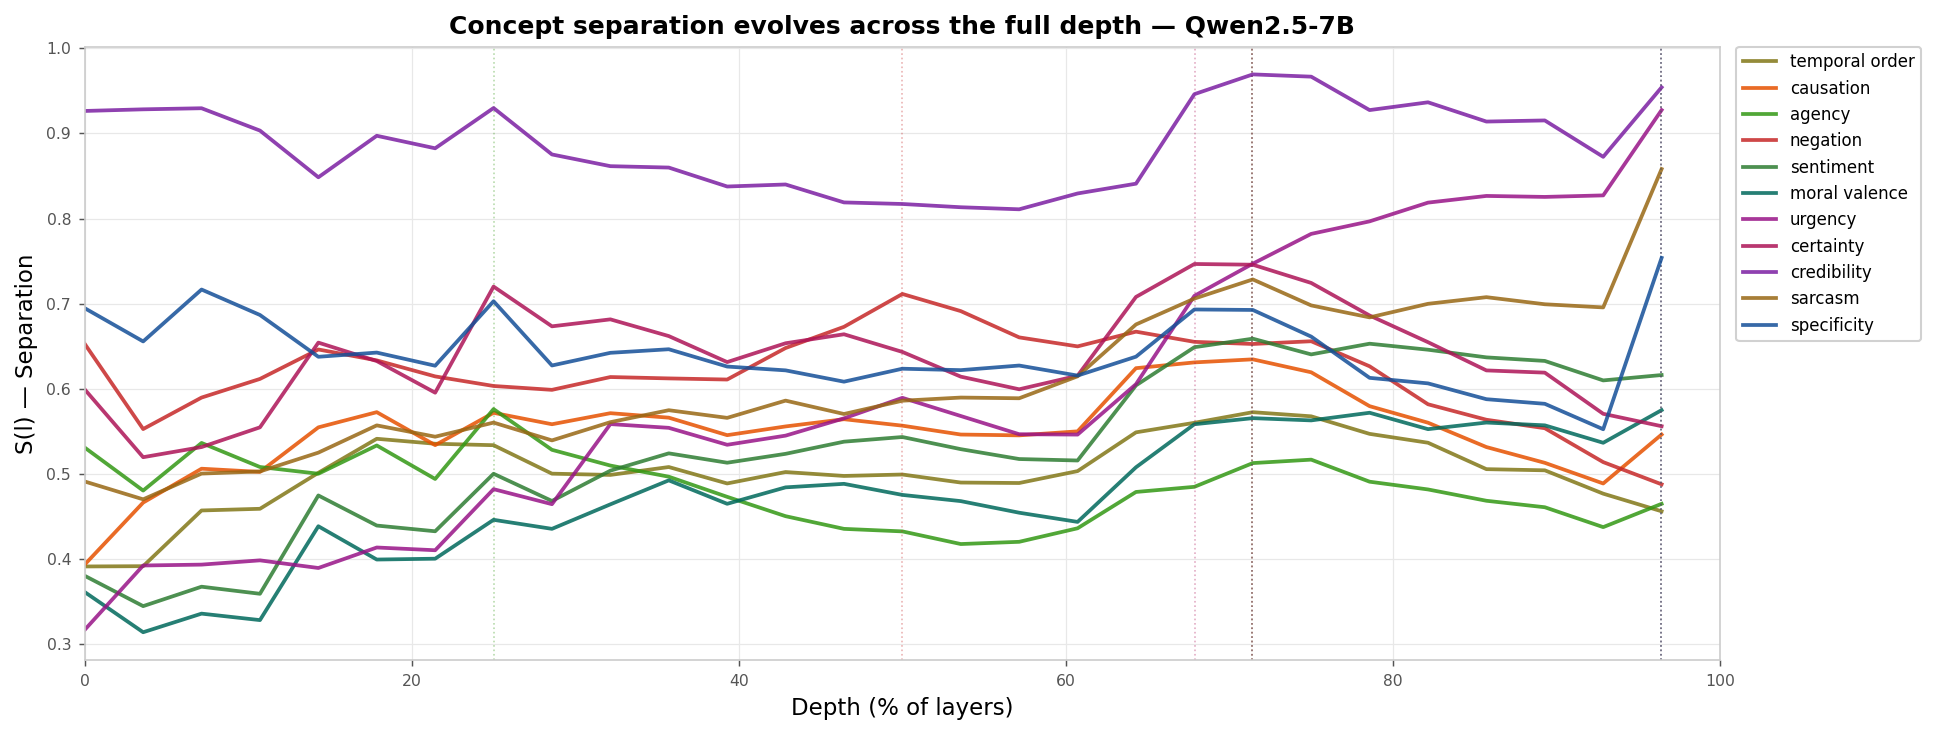

In [5]:
n_layers = caz[ALL_CONCEPTS[0]]["n_layers"]

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor("white")

for concept in ALL_CONCEPTS:
    metrics = caz[concept]["layer_data"]["metrics"]
    depth   = [m["layer"] / n_layers * 100 for m in metrics]
    sep     = [m["separation_fisher"] for m in metrics]
    peak    = caz[concept]["layer_data"]["peak_depth_pct"]
    color   = concept_color(concept)
    ax.plot(depth, sep, color=color, lw=1.8, alpha=0.85, label=concept.replace("_", " "))
    ax.axvline(peak, color=color, lw=0.8, ls=":", alpha=0.35)

ax.set_xlabel("Depth (% of layers)", fontsize=11)
ax.set_ylabel("S(l) — Separation", fontsize=11)
ax.set_title(f"Concept separation evolves across the full depth — {PRIMARY_LABEL}",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, 100)
ax.legend(fontsize=8, ncol=1, bbox_to_anchor=(1.01, 1), loc="upper left",
          borderaxespad=0, framealpha=0.9)
apply_theme(ax)
plt.tight_layout()
plt.show()

Concept representations are not assembled at a single point — they build, shift, and refine continuously across many layers. The S(l) curves above are broad distributions, not spikes: *agency* has measurable separation as early as 10%, *certainty* stays elevated from 50% through 90%, and several concepts reach their peak at overlapping depths around 70%.

This matters for how we think about existing interpretability tools. State-of-the-art **Sparse Autoencoders (SAEs)** — such as Gemma Scope or Anthropic's published work — are trained on the residual stream activations at a single chosen layer. In the chart above, that corresponds to a **vertical slice** at one depth percentage. The SAE captures a snapshot of which features exist at that moment, but the full construction trajectory — the buildup before, the refinement after — is outside its view.

The zone-based approach treats that vertical slice as one frame in a longer process. Instead of asking *what features exist at layer L*, we ask *over what depth range is each concept being actively constructed*.

## 2. The three signals

The CAZ framework tracks concept construction through three layer-wise signals:

| Signal | Symbol | What it measures |
|--------|--------|-----------------|
| **Separation** | $S(l)$ | Fisher-normalised centroid distance — how far apart the positive and negative class representations are, scaled by within-class scatter |
| **Coherence** | $C(l)$ | Mean cosine similarity to class centroid — how geometrically organised each class is internally |
| **Velocity** | $v(l)$ | Rate of change of $S(l)$ |

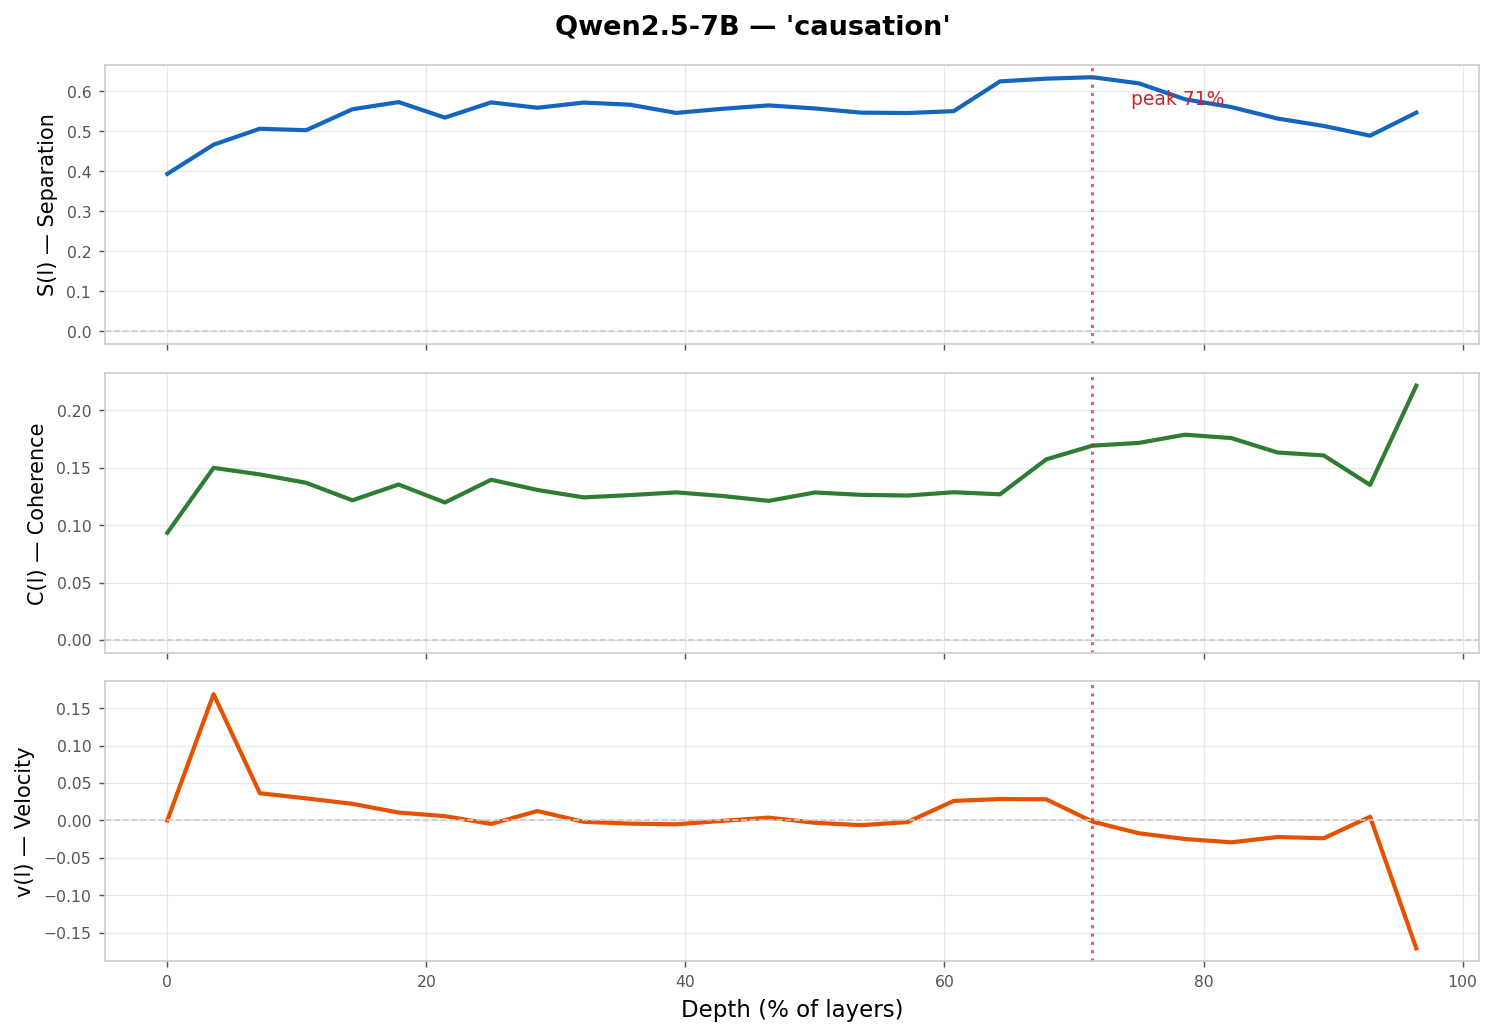

In [6]:
concept = "causation"
d = caz[concept]
metrics = d["layer_data"]["metrics"]
depth_x = [m["layer"] / d["n_layers"] * 100 for m in metrics]

SIG_COLORS = {"sep": "#1565C0", "coh": "#2E7D32", "vel": "#E65100"}

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
fig.patch.set_facecolor("white")
fig.suptitle(f"{PRIMARY_LABEL} — '{concept}'", fontsize=13, fontweight="bold")

for ax, key, ylabel, color in zip(
    axes,
    ["separation_fisher", "coherence", "velocity"],
    ["S(l) — Separation", "C(l) — Coherence", "v(l) — Velocity"],
    [SIG_COLORS["sep"], SIG_COLORS["coh"], SIG_COLORS["vel"]],
):
    vals = [m[key] for m in metrics]
    ax.plot(depth_x, vals, color=color, lw=2)
    ax.axhline(0, color=THEME["spine"], lw=0.8, ls="--")
    ax.set_ylabel(ylabel, fontsize=10)
    apply_theme(ax)

peak_pct = d["layer_data"]["peak_depth_pct"]
for ax in axes:
    ax.axvline(peak_pct, color="#C62828", lw=1.5, ls=":", alpha=0.7)
axes[0].annotate(f"peak {peak_pct:.0f}%",
                 xy=(peak_pct, axes[0].get_ylim()[1]),
                 xytext=(peak_pct + 3, axes[0].get_ylim()[1] * 0.85),
                 color="#C62828", fontsize=9)
axes[-1].set_xlabel("Depth (% of layers)", fontsize=11)
plt.tight_layout()
plt.show()

**Velocity** (orange) peaks just *before* **separation** (blue) — it is the leading edge, marking where the model starts building the representation, not where it finishes. **Coherence** (green) rises and stays elevated, confirming the class geometry is genuinely organised rather than just having scattered centroids.

Together, the velocity rise marks the *onset* of assembly and the separation peak marks the *completion*. The region between them is the Concept Allocation Zone.

## 3. Zone anatomy

A CAZ is not just a peak — it has a **start**, a **peak**, and an **end**. `find_caz_regions` from `rosetta_tools` detects the full extent.

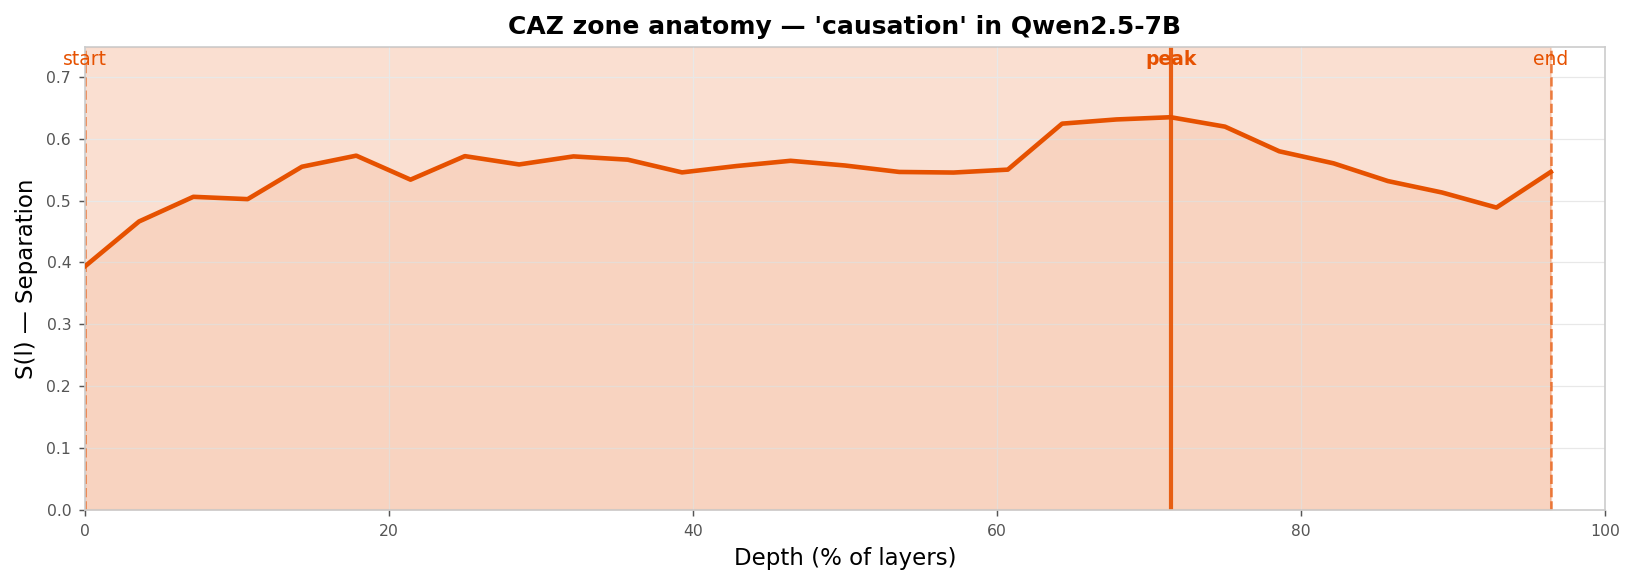

Zone: 0% → 71% (peak) → 96%   width = 96 pp


In [7]:
from rosetta_tools.caz import LayerMetrics, find_caz_regions

concept = "causation"
d = caz[concept]
metrics = d["layer_data"]["metrics"]
n_layers = d["n_layers"]
depth_x = [m["layer"] / n_layers * 100 for m in metrics]
sep     = [m["separation_fisher"] for m in metrics]

lm = [LayerMetrics(layer=m["layer"], separation=m["separation_fisher"],
                   coherence=m["coherence"], velocity=m["velocity"]) for m in metrics]
profile = find_caz_regions(lm)
region  = profile.dominant

s_pct = region.start / n_layers * 100
e_pct = region.end   / n_layers * 100
color = concept_color(concept)

fig, ax = plt.subplots(figsize=(11, 4))
fig.patch.set_facecolor("white")

ax.plot(depth_x, sep, color=color, lw=2.2, zorder=3)
ax.fill_between(depth_x, sep, alpha=0.08, color=color, zorder=2)
ax.axvspan(s_pct, e_pct, alpha=0.18, color=color, zorder=1)
ax.axvline(s_pct,              color=color, lw=1.2, ls="--", alpha=0.7)
ax.axvline(region.depth_pct,   color=color, lw=2.0, ls="-",  alpha=0.9)
ax.axvline(e_pct,              color=color, lw=1.2, ls="--", alpha=0.7)

ymax = max(sep) * 1.18
ax.text(s_pct,            ymax * 0.96, "start", color=color, fontsize=9, ha="center")
ax.text(region.depth_pct, ymax * 0.96, "peak",  color=color, fontsize=9, ha="center", fontweight="bold")
ax.text(e_pct,            ymax * 0.96, "end",   color=color, fontsize=9, ha="center")

ax.set_xlabel("Depth (% of layers)", fontsize=11)
ax.set_ylabel("S(l) — Separation", fontsize=11)
ax.set_ylim(0, ymax)
ax.set_xlim(0, 100)
ax.set_title(f"CAZ zone anatomy — '{concept}' in {PRIMARY_LABEL}", fontsize=12, fontweight="bold")
apply_theme(ax)
plt.tight_layout()
plt.show()
print(f"Zone: {s_pct:.0f}% → {region.depth_pct:.0f}% (peak) → {e_pct:.0f}%   width = {e_pct-s_pct:.0f} pp")

The shaded region is the zone extent — from where velocity first crosses threshold (start) to where separation drops off (end). The width reflects how precisely the concept is localised: a narrow zone means rapid, concentrated assembly; a wide zone means the process is distributed across many layers.

This is **single-peak (unimodal) analysis** — one assembly event, one zone. Many concepts are unimodal. But some show two or more distinct peaks, and treating a multimodal concept as unimodal collapses two separate events into one noisy blur. That is the next section.

## 4. Multimodal allocation

Some concepts assemble in more than one event. Pythia-160M is the richest example in our dataset — 9 of 11 concepts are multimodal, with some reaching four distinct zones. The four panels below show the full spectrum: one zone through four.

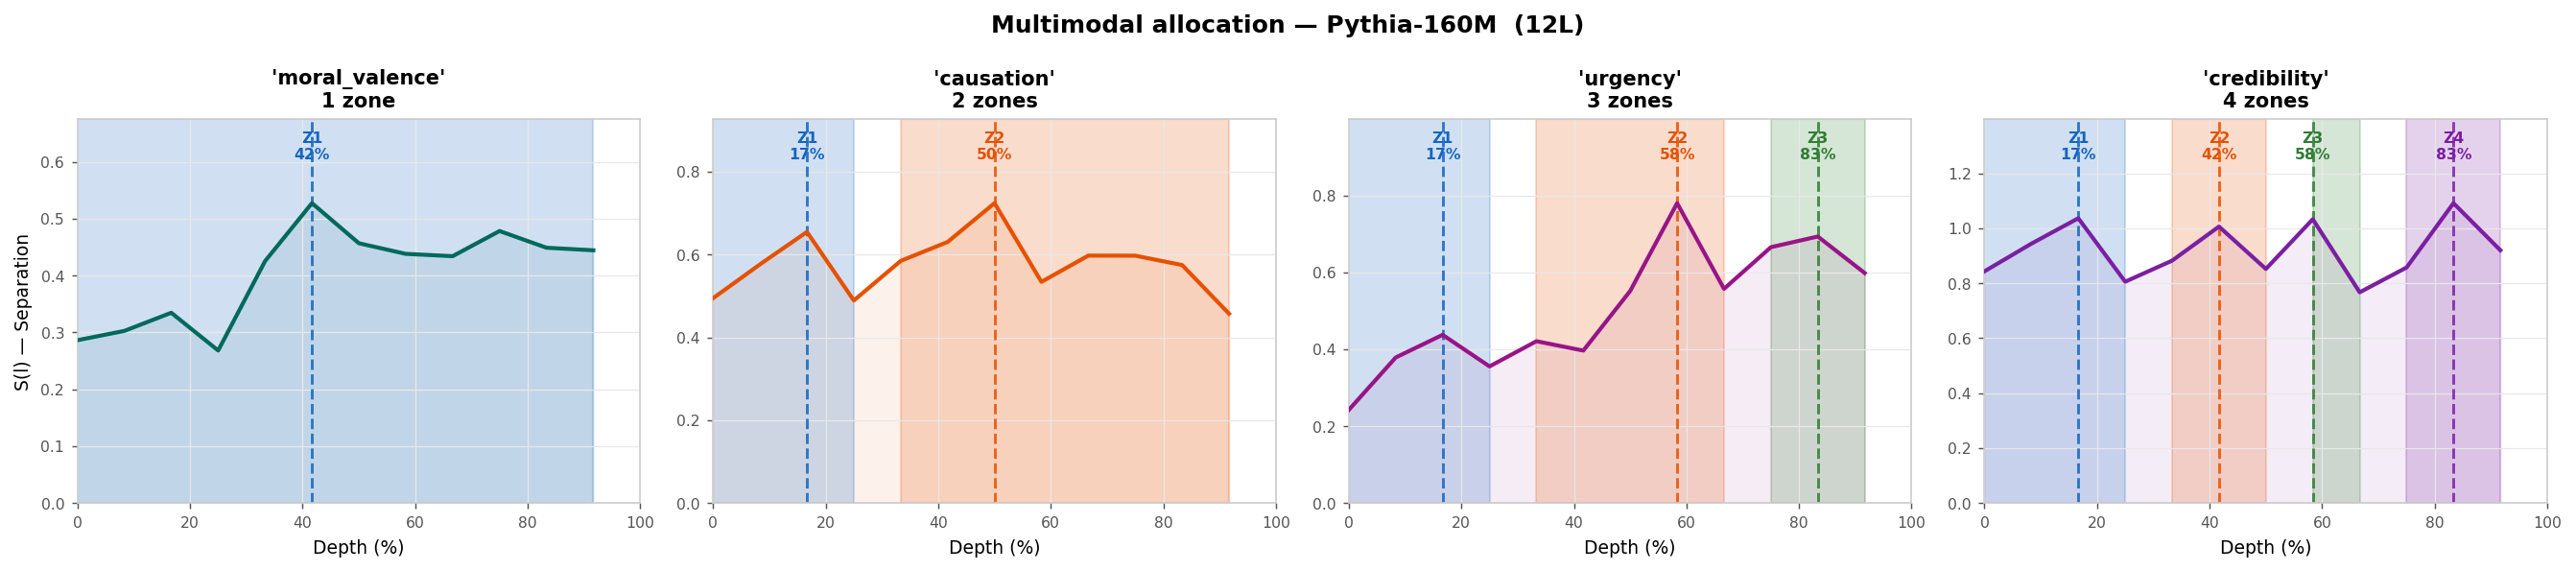

In [8]:
MULTIMODAL_MODEL = "EleutherAI/pythia-160m"
MULTIMODAL_LABEL = "Pythia-160M"

caz_p160m = {}
for concept in ALL_CONCEPTS:
    filename = f"models/{model_key(MULTIMODAL_MODEL)}/caz_{concept}.json"
    path = hf_hub_download(HF_REPO, filename=filename, repo_type="dataset")
    with open(path) as f:
        caz_p160m[concept] = json.load(f)

# 1 zone → 2 zones → 3 zones → 4 zones
DEMO_MM = ["moral_valence", "causation", "urgency", "credibility"]
ZONE_SHADE = ["#1565C0", "#E65100", "#2E7D32", "#7B1FA2"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
fig.patch.set_facecolor("white")
fig.suptitle(f"Multimodal allocation — {MULTIMODAL_LABEL}  (12L)",
             fontsize=12, fontweight="bold")

for ax, concept in zip(axes, DEMO_MM):
    d = caz_p160m[concept]
    metrics  = d["layer_data"]["metrics"]
    n_layers = d["n_layers"]
    depth_x  = [m["layer"] / n_layers * 100 for m in metrics]
    sep      = [m["separation_fisher"] for m in metrics]

    lm = [LayerMetrics(layer=m["layer"], separation=m["separation_fisher"],
                       coherence=m["coherence"], velocity=m["velocity"]) for m in metrics]
    profile = find_caz_regions(lm)

    color = concept_color(concept)
    ax.plot(depth_x, sep, color=color, lw=2.0, zorder=3)
    ax.fill_between(depth_x, sep, alpha=0.08, color=color)

    ymax = max(sep) * 1.28
    for i, region in enumerate(profile.regions):
        s_pct = region.start / n_layers * 100
        e_pct = region.end   / n_layers * 100
        zc = ZONE_SHADE[i % len(ZONE_SHADE)]
        ax.axvspan(s_pct, e_pct, alpha=0.20, color=zc, zorder=1)
        ax.axvline(region.depth_pct, color=zc, lw=1.4, ls="--", alpha=0.85)
        # annotate peak depth directly on the line — no legend box needed
        ax.text(region.depth_pct, ymax * 0.97,
                f"Z{i+1}\n{region.depth_pct:.0f}%",
                ha="center", va="top", fontsize=7.5,
                color=zc, fontweight="bold", clip_on=False)

    n = profile.n_regions
    ax.set_title(f"'{concept}'\n{n} zone{'s' if n > 1 else ''}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Depth (%)", fontsize=9)
    if ax is axes[0]:
        ax.set_ylabel("S(l) — Separation", fontsize=9)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, ymax)
    apply_theme(ax)

plt.tight_layout()
plt.show()

`moral_valence` (left) is unimodal — one clean assembly event. `causation` splits into two: a shallow pass and a deeper integration. `urgency` has three events spread across the full depth. `credibility` reaches four zones, peaking at roughly 17%, 42%, 58%, and 83% — assembling in overlapping phases rather than one coherent burst.

A probe positioned at any single layer captures at most one of `credibility`'s four events and misses the rest entirely.

## 5. GEM — the direction also evolves

The sections above track *amplitude*: how strongly a concept is expressed at each layer. The **Geometric Evolution Map (GEM)** tracks the other half: which *direction* in activation space the concept occupies.

The dominant direction $\hat{d}(l)$ — the unit vector from negative to positive class centroid — rotates as representations are refined. The layer-to-layer cosine $\cos(\hat{d}_l,\, \hat{d}_{l-1})$ gives a **direction stability** signal: values near 1.0 mean the direction barely moved; a sharp drop marks a **handoff point** where the geometric basis shifts.

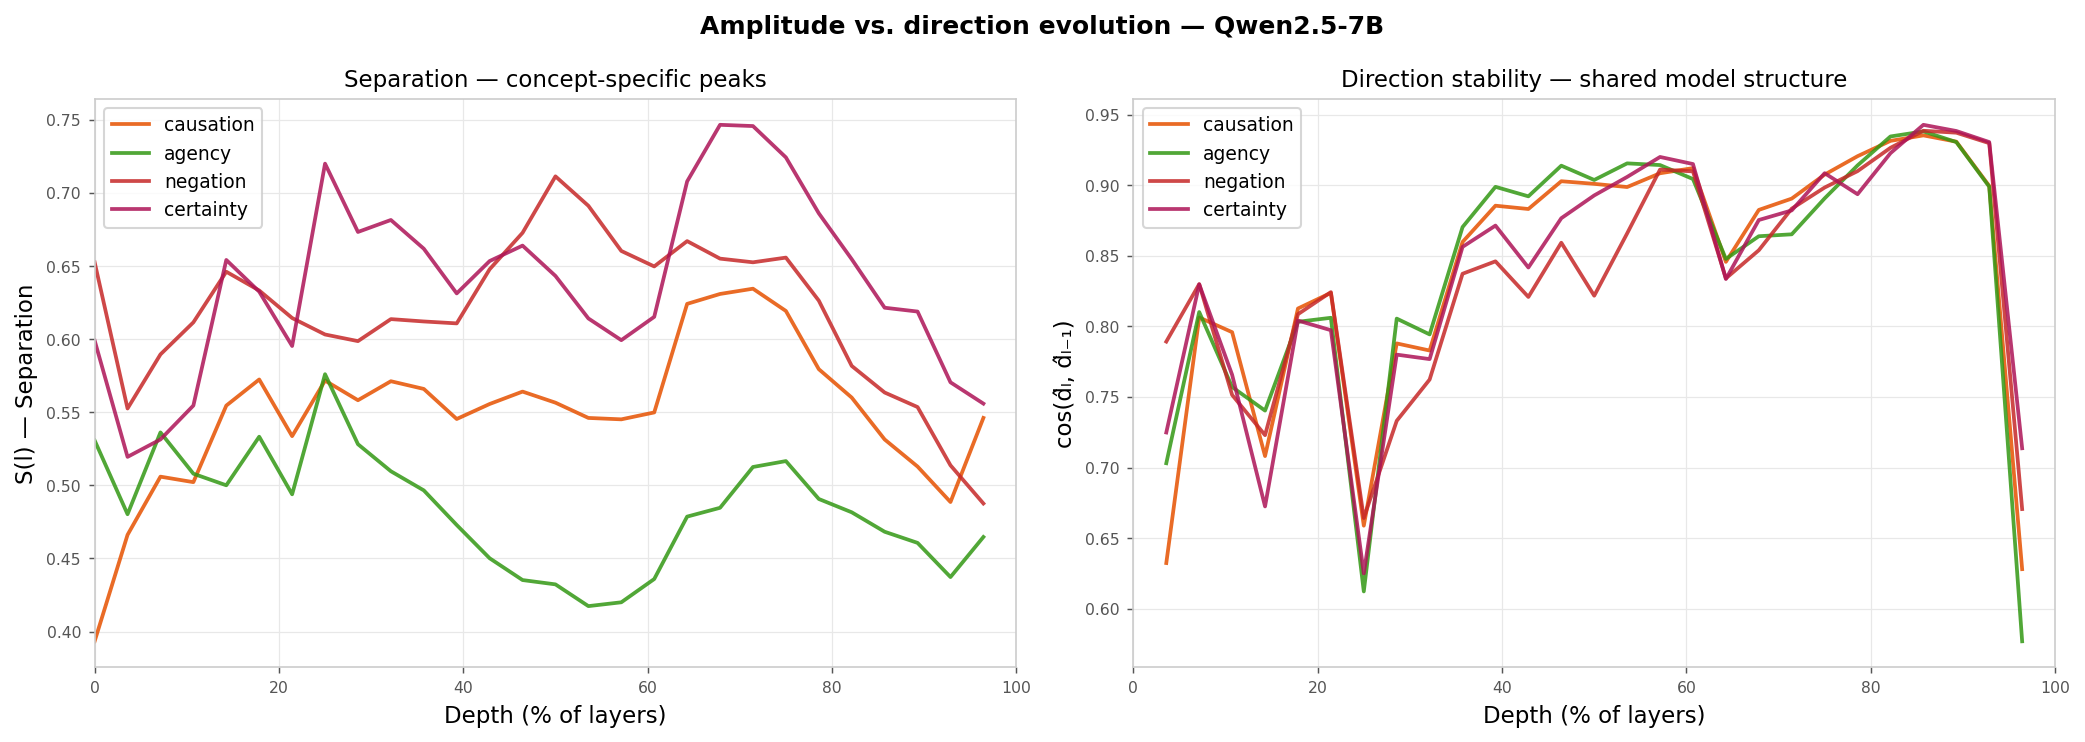

In [9]:
DEMO_CONCEPTS = ["causation", "agency", "negation", "certainty"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("white")
fig.suptitle(f"Amplitude vs. direction evolution — {PRIMARY_LABEL}",
             fontsize=12, fontweight="bold")

nl = caz[ALL_CONCEPTS[0]]["n_layers"]
depth_x = [l / nl * 100 for l in range(nl)]

for concept in DEMO_CONCEPTS:
    color   = concept_color(concept)
    metrics = caz[concept]["layer_data"]["metrics"]
    sep     = [m["separation_fisher"] for m in metrics]
    vecs    = [np.array(m["dom_vector"]) for m in metrics]

    dir_cos = [np.nan]   # no predecessor at layer 0
    for i in range(1, len(vecs)):
        v0, v1 = vecs[i-1], vecs[i]
        cos = float(np.dot(v0, v1) / (np.linalg.norm(v0) * np.linalg.norm(v1) + 1e-12))
        dir_cos.append(cos)

    label = concept.replace("_", " ")
    axes[0].plot(depth_x, sep,     color=color, lw=1.8, alpha=0.85, label=label)
    axes[1].plot(depth_x, dir_cos, color=color, lw=1.8, alpha=0.85, label=label)

axes[0].set_title("Separation — concept-specific peaks",       fontsize=11)
axes[0].set_ylabel("S(l) — Separation",                        fontsize=11)
axes[1].set_title("Direction stability — shared model structure", fontsize=11)
axes[1].set_ylabel("cos(d̂ₗ, d̂ₗ₋₁)",                          fontsize=11)

for ax in axes:
    ax.set_xlabel("Depth (% of layers)", fontsize=11)
    ax.set_xlim(0, 100)
    ax.legend(fontsize=9, loc="upper left")
    apply_theme(ax)

plt.tight_layout()
plt.show()

The asymmetry is striking. **Separation** (left) peaks at different depths for each concept — the amplitude story is concept-specific. **Direction stability** (right) dips at the *same* layers for all four concepts — the handoff structure is a property of the model architecture, not of any individual concept.

Four semantically unrelated concepts — what a sentence *causes*, who *acts*, what is *negated*, what is *certain* — all undergo their geometric basis changes at the same moments. The model is not maintaining separate directional machinery for each concept. It has one shared transformation schedule that all semantic content moves through.

Look at the right panel carefully. The four curves are almost locked together: every dip, every recovery, every plateau is shared. At roughly 25% depth, all four concepts simultaneously lose directional stability — the geometric basis shifts beneath them all at once. The same happens at ~55% and again at ~80%. None of this is driven by what the concept *means*. It is driven by what the model *does* at each stage of processing.

**This is what it looks like when a model thinks.** The concept-specific peaks in the left panel tell you *what* the model is representing at each depth. The shared dips in the right panel reveal the underlying architecture of *how* it reorganises representations — the moments of structural transition that run underneath all semantic content simultaneously.

The core GEM insight: *where* a concept crystallises is concept-specific; *how* the model's geometric machinery transitions is shared infrastructure. The two signals decompose a model's internal activity into content and structure — and they evolve almost independently of each other.

In [ ]:
# Direction stability — same four concepts, two architectures
DEMO_CONCEPTS = ["causation", "agency", "negation", "certainty"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Direction stability is model-structural — the same pattern in two different architectures",
    fontsize=12, fontweight="bold",
)

model_panels = [
    (caz,       PRIMARY_LABEL,    f"{caz[ALL_CONCEPTS[0]]['n_layers']} layers"),
    (caz_p160m, MULTIMODAL_LABEL, f"{caz_p160m[ALL_CONCEPTS[0]]['n_layers']} layers"),
]

for ax, (data, label, depth_desc) in zip(axes, model_panels):
    nl = data[ALL_CONCEPTS[0]]["n_layers"]
    depth_x = [l / nl * 100 for l in range(nl)]

    for concept in DEMO_CONCEPTS:
        color   = concept_color(concept)
        metrics = data[concept]["layer_data"]["metrics"]
        vecs    = [np.array(m["dom_vector"]) for m in metrics]

        dir_cos = [np.nan]
        for i in range(1, len(vecs)):
            v0, v1 = vecs[i - 1], vecs[i]
            cos = float(np.dot(v0, v1) / (np.linalg.norm(v0) * np.linalg.norm(v1) + 1e-12))
            dir_cos.append(cos)

        ax.plot(depth_x, dir_cos, color=color, lw=1.8, alpha=0.85,
                label=concept.replace("_", " "))

    ax.set_title(f"{label}  ({depth_desc})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Depth (% of layers)", fontsize=11)
    ax.set_ylabel("cos(d̂ₗ, d̂ₗ₋₁) — direction stability", fontsize=10)
    ax.set_xlim(0, 100)
    ax.legend(fontsize=9, loc="lower left")
    apply_theme(ax)

plt.tight_layout()
plt.show()

The two panels use completely different architectures — Qwen2.5-7B has 28 layers and a grouped-query attention mechanism; Pythia-160M has 12 layers and standard multi-head attention. Their handoff schedules are different: the specific depths at which geometric transitions occur are architecture-specific.

But in each panel, the four concept curves move together. Causation, agency, negation, and certainty are not sharing a handoff schedule with each other because of anything they have in common semantically — they share it because they are all passing through the *same model*. Every concept processed by a given architecture follows that architecture's structural rhythm.

This has a practical implication. When you observe a direction stability dip in a single concept, you cannot conclude that *this concept* is undergoing something special — you are observing the model's architectural machinery firing, which affects everything at once. To isolate a concept-specific signal, you need to subtract the shared structural baseline. GEM provides both the signal and its decomposition.

## 6. Concept topology — the full picture

With the vocabulary established, here is the complete concept topology of Pythia-160M — the model with the richest multimodal structure in the dataset. Bars span each zone's start-to-end extent; dots mark peaks; faded bars are secondary zones.

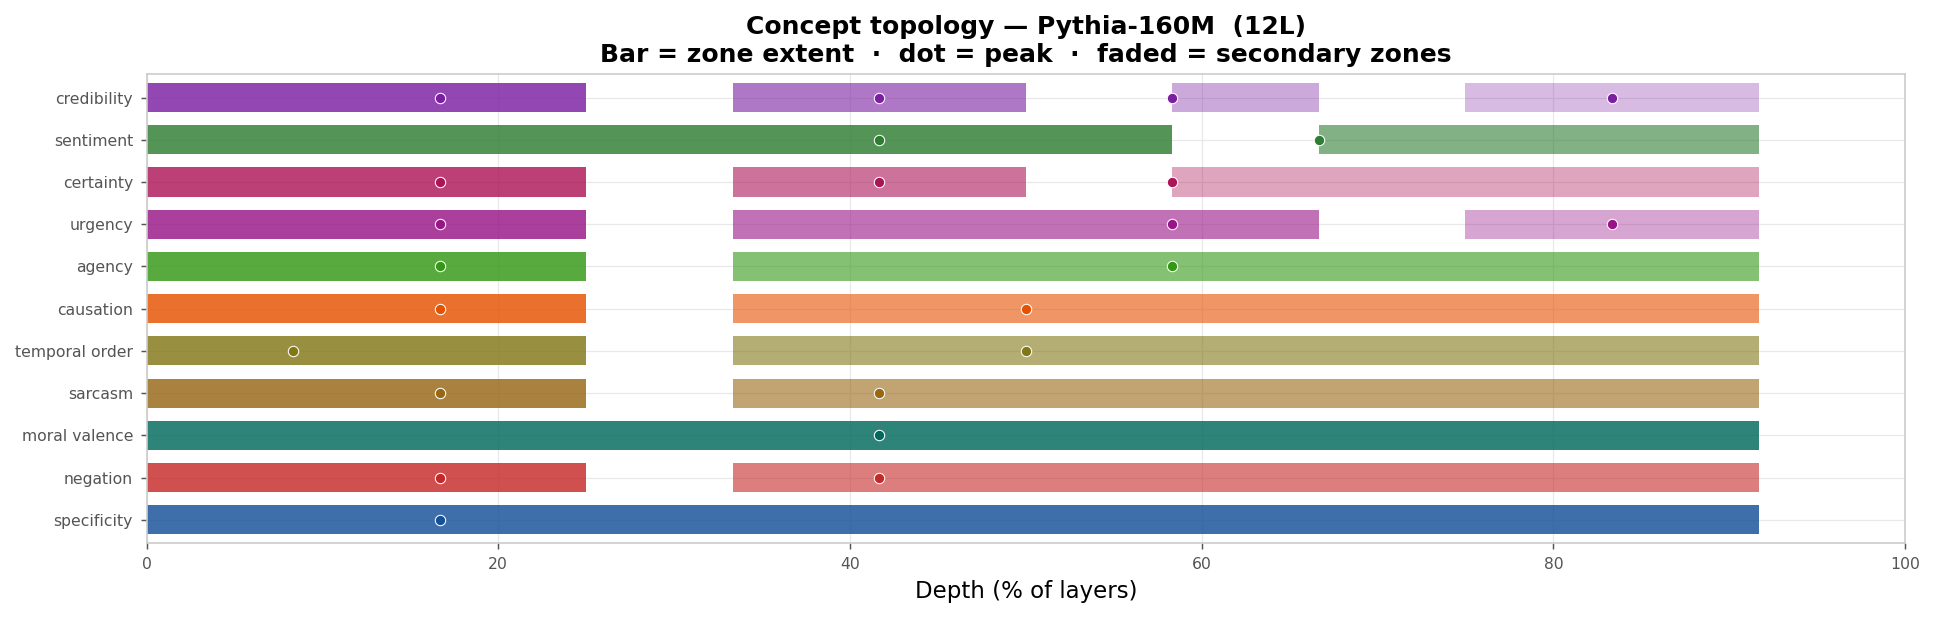

In [10]:
concept_order = sorted(ALL_CONCEPTS, key=lambda c: caz_p160m[c]["layer_data"]["peak_depth_pct"])

bar_h      = 0.22
row_gap    = 0.10                        # whitespace between rows = gap only, not extra padding
row_step   = bar_h + row_gap
n_rows     = len(concept_order)
fig_h      = n_rows * row_step + 0.70   # 0.70 for title + xlabel

fig, ax = plt.subplots(figsize=(13, fig_h))
fig.patch.set_facecolor("white")

for ci, concept in enumerate(concept_order):
    y = ci * row_step
    d = caz_p160m[concept]
    n_layers = d["n_layers"]
    metrics  = d["layer_data"]["metrics"]
    lm = [LayerMetrics(layer=m["layer"], separation=m["separation_fisher"],
                       coherence=m["coherence"], velocity=m["velocity"]) for m in metrics]
    profile = find_caz_regions(lm)
    color = concept_color(concept)

    for i, region in enumerate(profile.regions):
        s_pct = region.start / n_layers * 100
        e_pct = region.end   / n_layers * 100
        alpha = max(0.82 - i * 0.22, 0.30)
        ax.barh(y, e_pct - s_pct, left=s_pct, height=bar_h,
                color=color, alpha=alpha, zorder=2)
        ax.plot(region.depth_pct, y, "o", color=color, ms=5, zorder=3,
                markeredgecolor="white", markeredgewidth=0.5)

y_positions = [ci * row_step for ci in range(n_rows)]
ax.set_yticks(y_positions)
ax.set_yticklabels([c.replace("_", " ") for c in concept_order], fontsize=10)
ax.set_ylim(-bar_h * 0.8, (n_rows - 1) * row_step + bar_h * 0.8)
ax.set_xlabel("Depth (% of layers)", fontsize=11)
ax.set_xlim(0, 100)
ax.set_title(f"Concept topology — {MULTIMODAL_LABEL}  ({d['n_layers']}L)\n"
             "Bar = zone extent  ·  dot = peak  ·  faded = secondary zones",
             fontsize=12, fontweight="bold")
apply_theme(ax)
plt.tight_layout()
plt.show()

Only two concepts in Pythia-160M are unimodal — the rest spread across multiple assembly events. Some early zones are shallow structural passes; later zones are deeper semantic integrations. The width variation is also visible: some concepts are tightly localised (short bars), others diffuse (long bars spanning a third of the model).

An interpretability method that probes a single layer is sampling one point in this landscape and treating it as the whole picture.

## Summary

| Section | What we covered |
|---------|----------------|
| 1. Single-layer problem | Concept representations build continuously across many layers; a single-layer probe (or SAE) captures one slice of a longer construction process |
| 2. Three signals | $S(l)$, $C(l)$, $v(l)$ — amplitude, organisation, and rate of change |
| 3. Zone anatomy | CAZ zones have start, peak, and end; width reflects how precisely a concept is localised |
| 4. Multimodal allocation | Some concepts assemble in multiple events; a single probe misses all but one |
| 5. GEM | The concept direction rotates layer-by-layer; handoff points are model-structural, not concept-specific |
| 6. Concept topology | A full portrait of one model's internal concept landscape |

---

### Next notebooks

| Notebook | What it covers |
|----------|---------------|
| `02_caz_interactive_demo.ipynb` | Load Qwen2.5-7B (4-bit) and run CAZ on your own concept pairs |
| `03_caz_implementation_demo.ipynb` | Implement the metrics from scratch; reproduce the cross-architecture convergence result from Paper 4 |

### Papers and resources

| | |
|-|-|
| Paper 1 — CAZ Framework | [Henry 2026a](https://arxiv.org/abs/PLACEHOLDER) |
| Paper 2 — GEM | [Henry 2026b](https://arxiv.org/abs/PLACEHOLDER) |
| `rosetta_tools` | [GitHub](https://github.com/jamesrahenry/Rosetta_Tools) |
| Concept pairs dataset | [Rosetta_Concept_Pairs](https://github.com/jamesrahenry/Rosetta_Concept_Pairs) |